In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib import gridspec
import statsmodels.stats.proportion as proportion
import math

In [2]:
df = pd.read_csv('data16')
th_x, err_x = df.theta_x, df.err_x
th_y, err_y = df.theta_y, df.err_y

In [3]:
th_x = th_x[(th_x!=0) & (th_y!=0)]
th_y = th_y[(th_x!=0) & (th_y!=0)]

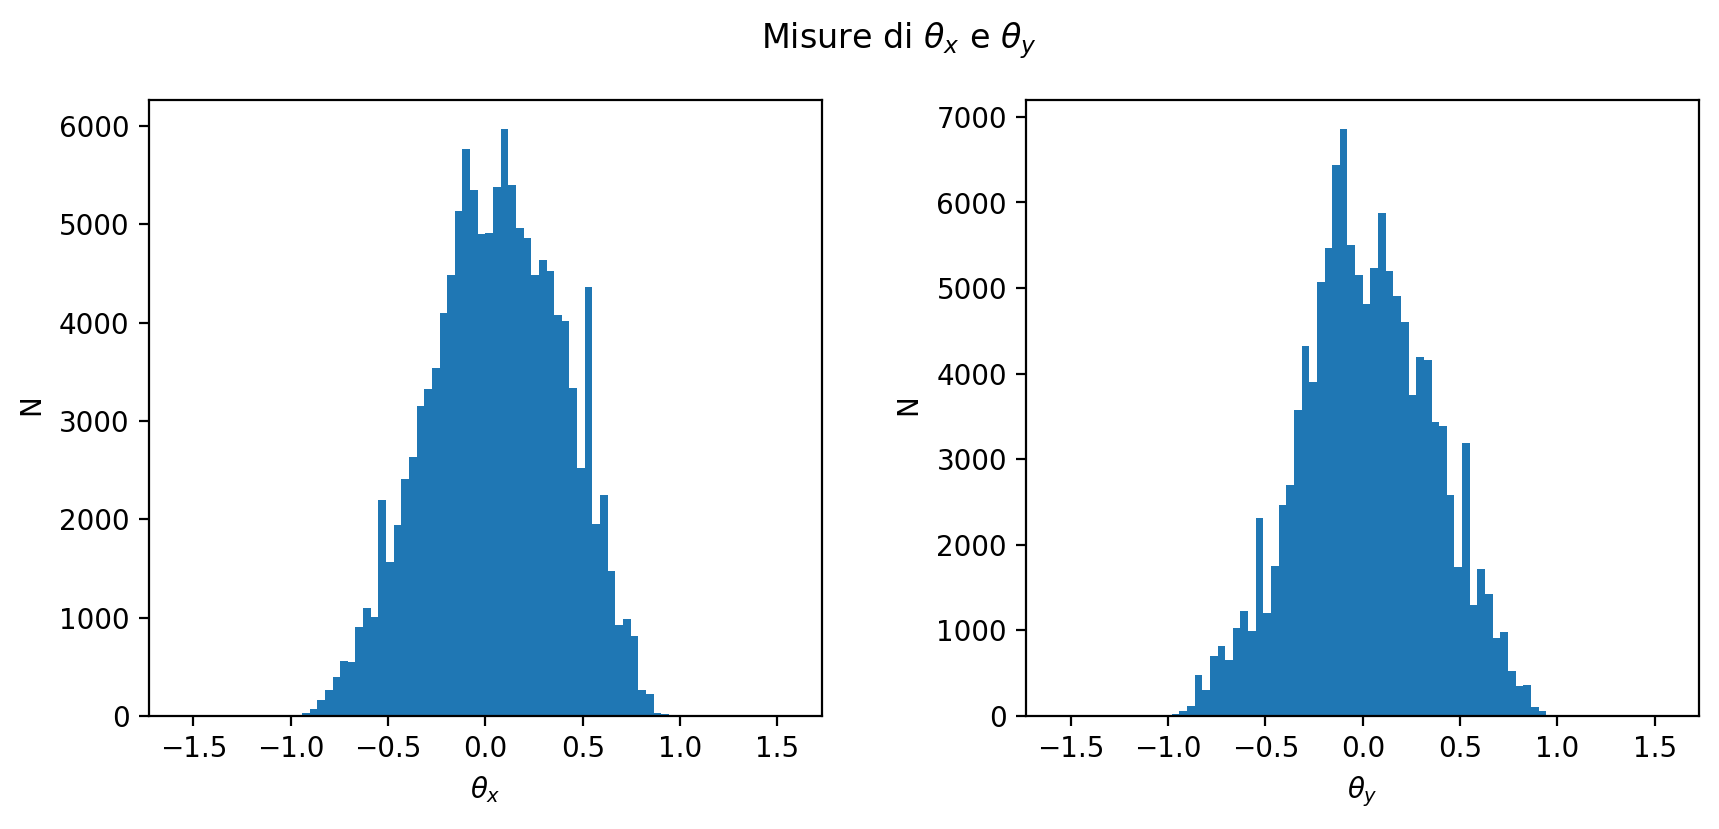

In [4]:
fig = plt.figure(figsize = (10, 4), dpi=200)
gs = gridspec.GridSpec(1, 9)
ax0 = fig.add_subplot(gs[:, :4])
ax1 = fig.add_subplot(gs[:, 5:])
nbins1 = 80
th_range = (-math.pi/2, math.pi/2)
n_x, bins_x, _ = ax0.hist(th_x, bins=nbins1, density=False, range=th_range)
ax0.set_xlabel(r'$\theta_x$')
ax0.set_ylabel(r'$\mathrm{N}$')
n_y, bins_y, _ = ax1.hist(th_y, bins=nbins1, density=False, range=th_range)
ax1.set_xlabel(r'$\theta_y$')
ax1.set_ylabel(r'$\mathrm{N}$')
plt.suptitle(r'Misure di $\theta_x$ e $\theta_y$')
plt.show()

In [5]:
mx = np.tan(th_x)
my = np.tan(th_y)
th_m = np.arccos(1/np.sqrt(mx**2+my**2+1))
ph_m = np.arctan2(my, mx)+np.pi

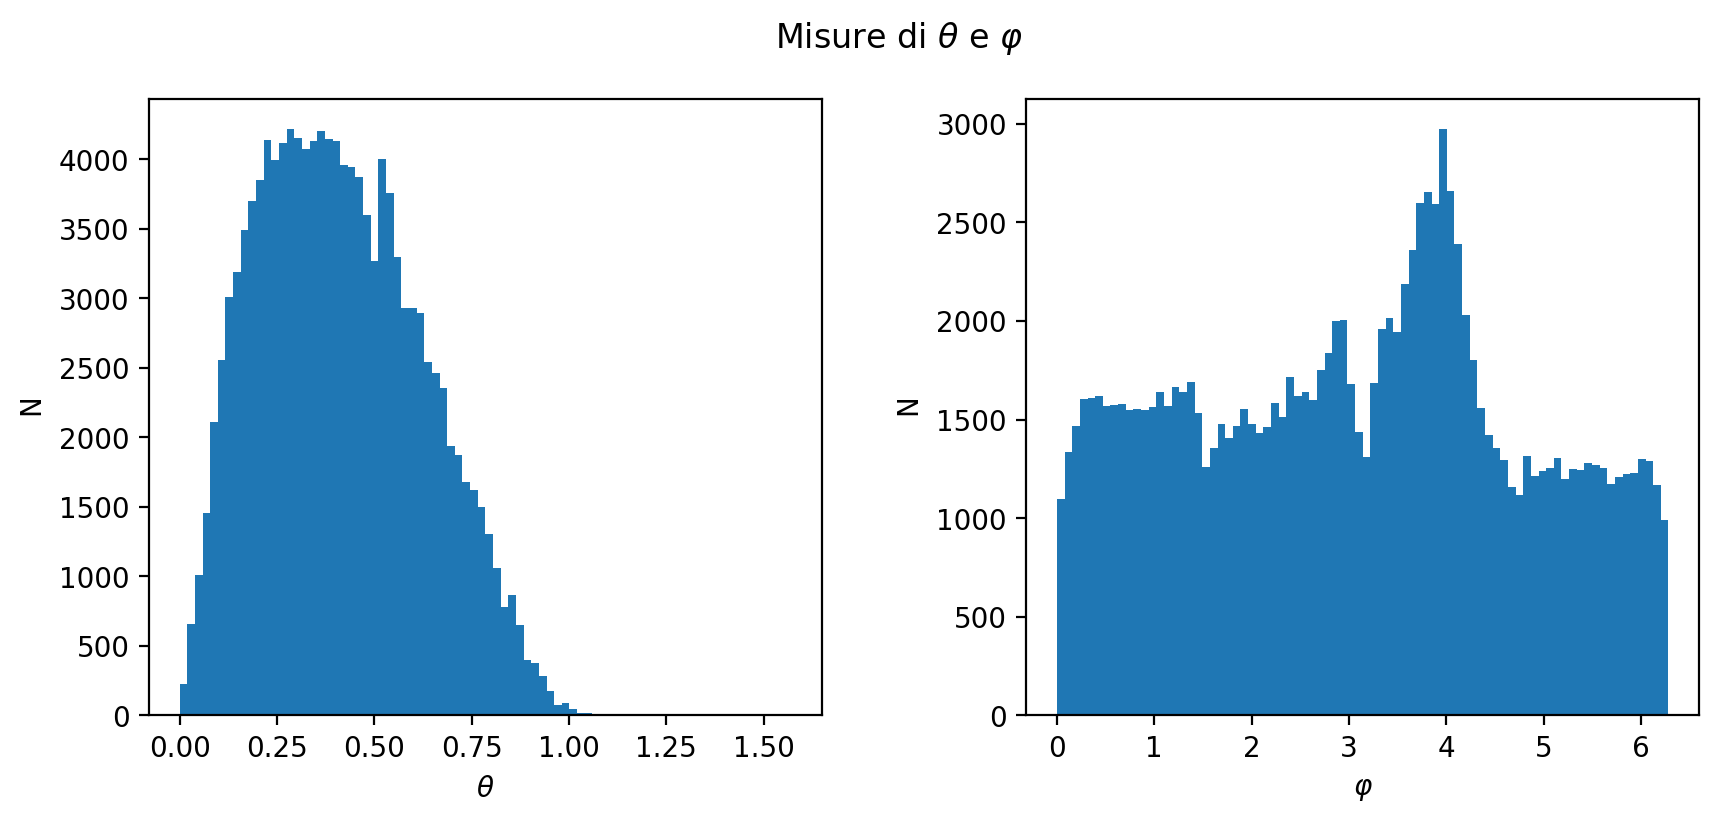

In [6]:
fig = plt.figure(figsize = (10, 4), dpi=200)
gs = gridspec.GridSpec(1, 9)
ax0 = fig.add_subplot(gs[:, :4])
ax1 = fig.add_subplot(gs[:, 5:])
th_range = (0, math.pi/2)
n_th_m, bins_th, _ = ax0.hist(th_m, bins=nbins1, density=False, range=th_range)
ax0.set_xlabel(r'$\theta$')
ax0.set_ylabel(r'$\mathrm{N}$')
ph_range = (0, 2*math.pi)
n_ph_m, bins_ph, _ = ax1.hist(ph_m, bins=nbins1, density=False, range=ph_range)
ax1.set_xlabel(r'$\varphi$')
ax1.set_ylabel(r'$\mathrm{N}$')
plt.suptitle(r'Misure di $\theta$ e $\varphi$')
plt.show()

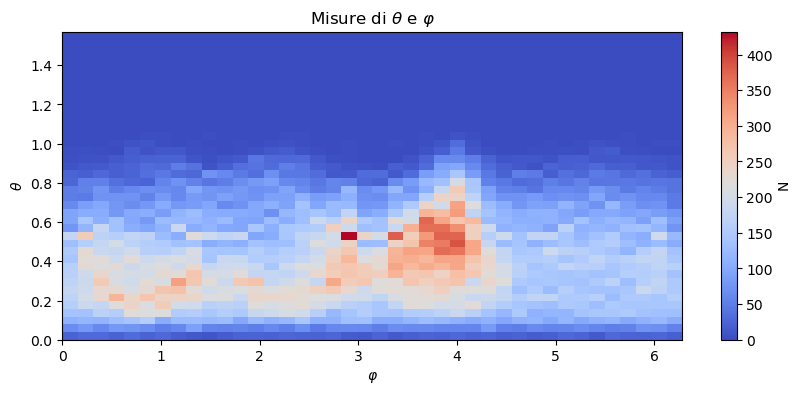

In [7]:
fig, ax = plt.subplots(figsize = (10, 4))
nbins2 = 40
h_m, phi_edges, theta_edges, im = ax.hist2d(ph_m, th_m, nbins2,
                                          range = (ph_range, th_range), density = False, cmap = 'coolwarm')
fig.colorbar(im, ax = ax, label = r'$\mathrm{N}$')
ax.set(xlabel = r'$\varphi$', ylabel = r'$\theta$')
plt.title(r'Misure di $\theta$ e $\varphi$')
plt.show()

In [8]:
L = 200
n_mc = 100000
l = 40
h = 7
n_p = 10
n_hit = 0
theta_hit, phi_hit = [], []
theta = np.arccos((1 - np.random.uniform(size = n_mc))**(1/3))
phi = 2*math.pi*np.random.uniform(size = n_mc)
st, ct, sp, cp = np.sin(theta), np.cos(theta), np.sin(phi), np.cos(phi)
us, vs, ws = st*cp, st*sp, ct
x0s = np.random.uniform(-L/2, L/2, size = n_mc)
y0s = np.random.uniform(-L/2, L/2, size = n_mc)
x1s = np.array([[x0 + (j*h)*(u/w) for j in range(n_p)] for x0, u, w in zip(x0s, us, ws)])
y1s = np.array([[y0 + (j*h)*(v/w) for j in range(n_p)] for y0, v, w in zip(y0s, vs, ws)])
hits = [((x>-l/2) & (x<l/2) & (y>-l/2) & (y<l/2)) for x, y in zip(x1s, y1s)]
for hit, th, ph in zip(hits, theta, phi):   
    '''
    if len(hit[hit==1])>2:
        n_hit+=1
        theta_hit.append(th)
        phi_hit.append(ph)
    '''
    led = True
    for i in range(0,5):
        if not any(hit[i:i+6]):
            led = False
    if led:
        n_hit+=1
        theta_hit.append(th)
        phi_hit.append(ph)
        
print("{:d}/{:d}".format(n_hit, n_mc))
eff = n_hit/(n_mc)
err = np.sqrt(eff*(1 - eff)/n_mc)
print("ε = {:.4f}±{:.4f}".format(eff, err))

4717/100000
ε = 0.0472±0.0007


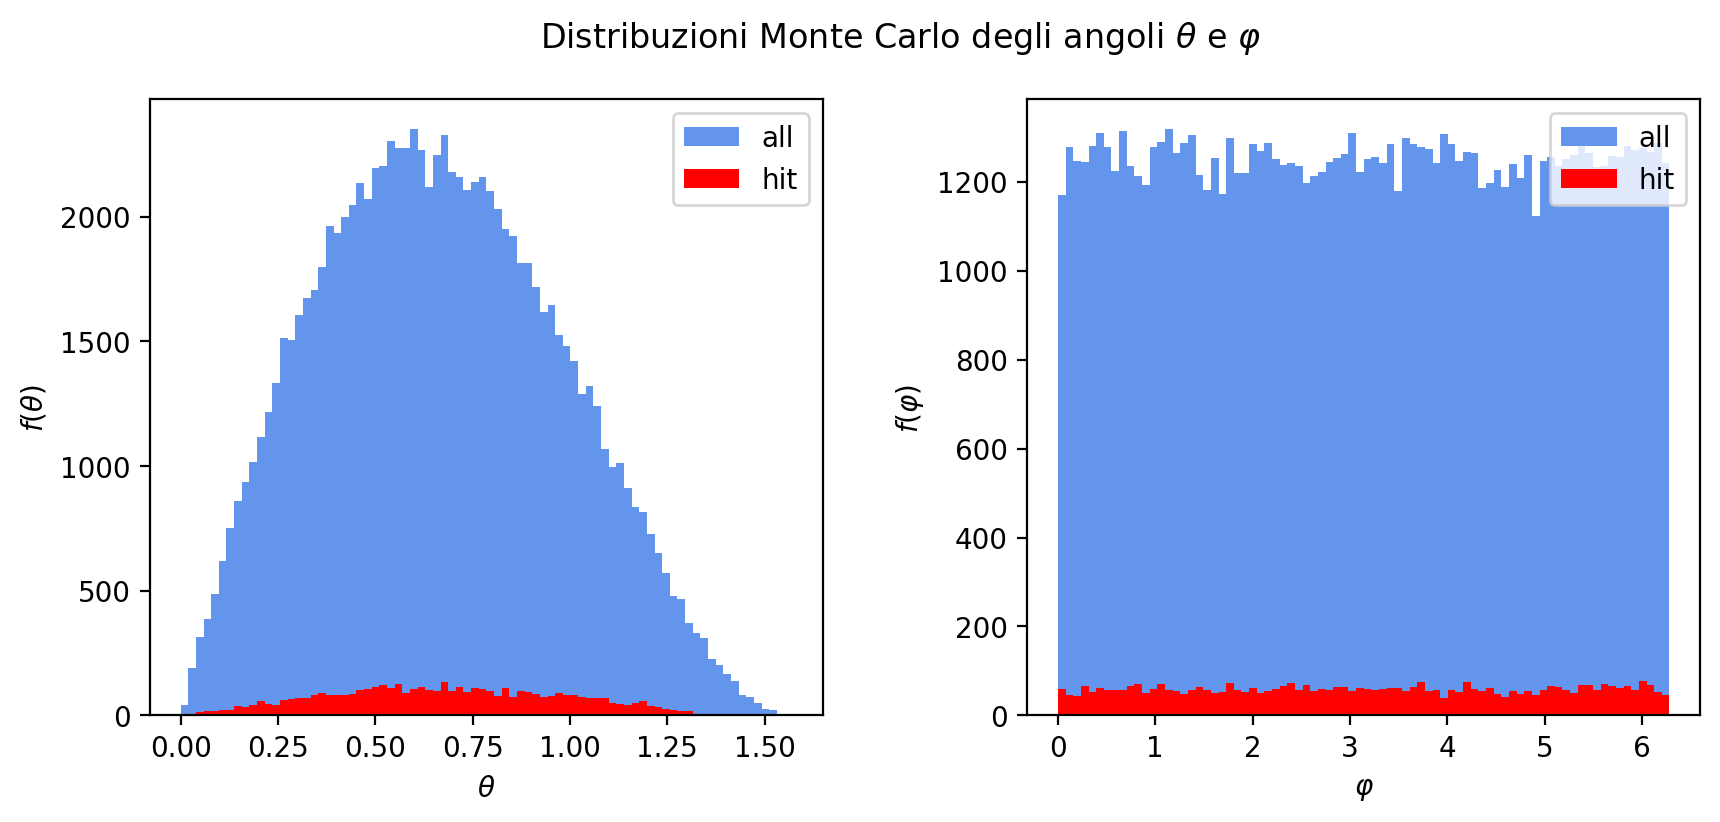

In [9]:
fig = plt.figure(figsize = (10, 4), dpi=200)
gs = gridspec.GridSpec(1, 9)
ax0 = fig.add_subplot(gs[:, :4])
ax1 = fig.add_subplot(gs[:, 5:])


n_th_t, _, _ = ax0.hist(theta, density=False, bins=nbins1, range=th_range, color='cornflowerblue', label='all')
n_th_h, _, _ = ax0.hist(theta_hit, density=False, bins=nbins1, range=th_range, color='red', label='hit')
ax0.set(xlabel=r'$\theta$', ylabel=r'$f(\theta)$')
ax0.legend()


n_ph_t, _, _ = ax1.hist(phi, density=False, bins=nbins1, range=ph_range, color='cornflowerblue', label='all')
n_ph_h, _, _ = ax1.hist(phi_hit, density=False, bins=nbins1, range=ph_range, color='red', label='hit')
ax1.set(xlabel=r'$\varphi$', ylabel=r'$f(\varphi)$')
ax1.legend()

plt.suptitle(r'Distribuzioni Monte Carlo degli angoli $\theta$ e $\varphi$')
plt.show()

In [10]:
th1, ph1 = (bins_th[1:]+bins_th[:-1])/2, (bins_ph[1:]+bins_ph[:-1])/2
delta_th1 = bins_th[1] - bins_th[0]
delta_ph1 = bins_ph[1] - bins_ph[0]
a_th = np.divide(n_th_h, n_th_t, out=np.zeros_like(n_th_t), where=n_th_t != 0)
a_ph = np.divide(n_ph_h, n_ph_t, out=np.zeros_like(n_ph_t), where=n_ph_t != 0)

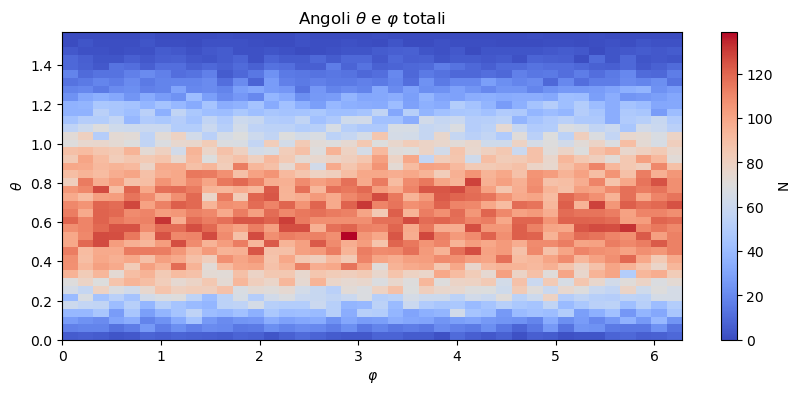

In [11]:
fig, ax = plt.subplots(figsize = (10, 4))
h_t, phi_edges, theta_edges, im = ax.hist2d(phi, theta, nbins2,
                                          range = (ph_range, th_range), density = False, cmap = 'coolwarm')
fig.colorbar(im, ax = ax, label = r'$\mathrm{N}$')
ax.set(xlabel = r'$\varphi$', ylabel = r'$\theta$')
plt.title(r'Angoli $\theta$ e $\varphi$ totali')
plt.show()

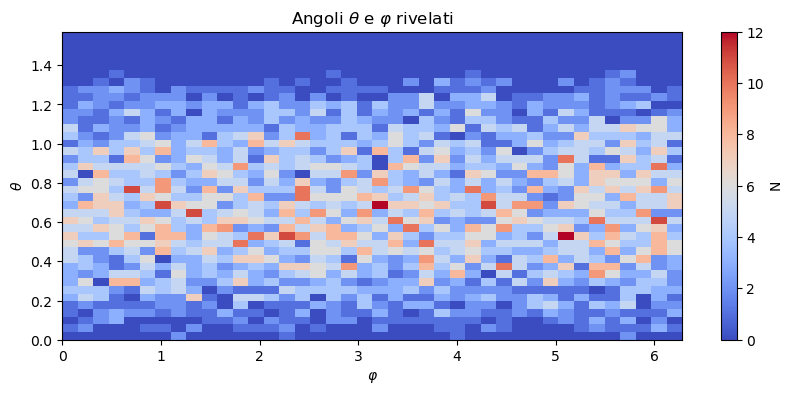

In [12]:
fig, ax = plt.subplots(figsize = (10, 4))
h_h, phi_edges, theta_edges, im = ax.hist2d(phi_hit, theta_hit, nbins2,
                                          range = (ph_range, th_range), density = False, cmap = 'coolwarm')
fig.colorbar(im, ax = ax, label = r'$\mathrm{N}$')
ax.set(xlabel = r'$\varphi$', ylabel = r'$\theta$')
plt.title(r'Angoli $\theta$ e $\varphi$ rivelati')
plt.show()

In [13]:
a_th_ph = np.divide(h_h, h_t, out=np.zeros_like(h_t), where=h_t!=0)
ph2, th2 = (phi_edges[1:]+phi_edges[:-1])/2, (theta_edges[1:]+theta_edges[:-1])/2
delta_th2 = theta_edges[1] - theta_edges[0]
delta_ph2 = phi_edges[1] - phi_edges[0]

In [14]:
t_tot = 104372 #min
n = 10 #plates
l = 40 #cm
L = 200 #cm
I0 = 4 #muon/min
acc = 0.0462
err = 0.0007

In [15]:
N_fs = t_tot*I0
print('N_fs = ', N_fs)

N_fs =  417488


In [16]:
def model_th(x):
    return 3*np.sin(x)*np.cos(x)**2

In [17]:
f_th = model_th(th1)
c_th = (f_th*a_th).sum()*delta_th1
c_ph = (a_ph/2/math.pi).sum()*delta_ph1
N_fs_th = N_fs*delta_th1*a_th*f_th/c_th
N_fs_ph = N_fs*delta_ph1*a_ph/2/np.pi/c_ph

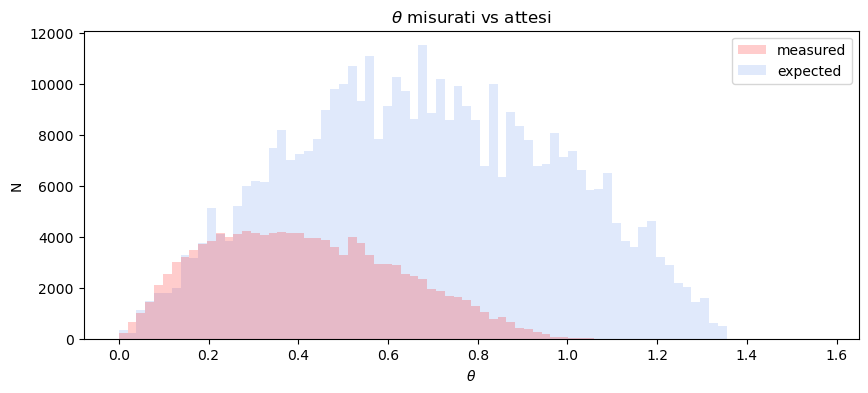

In [18]:
fig = plt.figure(figsize = (10, 4), dpi=100)
plt.bar(th1, N_fs_th, width = delta_th1, bottom=0, align='center', color='cornflowerblue', label='expected', alpha=0.2)
plt.hist(th_m, density=False, bins=nbins1, range=th_range, color='red', label='measured', alpha=0.2)
plt.xlabel(r'$\theta$')
plt.ylabel('N')
plt.title(r'$\theta$ misurati vs attesi')
plt.legend()
plt.show()